# Idea

load all MultiTaskLassoCV models and compare alpha parameters to determine best alpha.

# Imports

In [1]:
import os
# os.nice(19)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
model_name = 'MultiTaskLassoCV'
model_Nos = [1,3,4]
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Model

In [4]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/saved_models")
models = {}
scalers = {}
for model_No in model_Nos:
    model = joblib.load(MODEL_DIR / f'{model_name}_{target}_model_{model_No}.pkl')
    scaler = joblib.load(MODEL_DIR / f'{model_name}_{target}_scaler_{model_No}.pkl')

    models[model_No] = model
    scalers[model_No] = scaler
print(f"✅ Successfully loaded {len(models)} models and scalers.")

✅ Successfully loaded 3 models and scalers.


# Run Model

In [5]:
predicitions = {}
for model_No in model_Nos:
    model = models[model_No]
    scaler = scalers[model_No]

     # scale X_test
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        index=X_test.index,
        columns=X_test.columns
    )

    y_test_pred = pd.DataFrame(model.predict(X_test_scaled), index=X_test.index, columns=y_test.columns)
    predicitions[model_No] = y_test_pred

# Results

## Check Coefficients

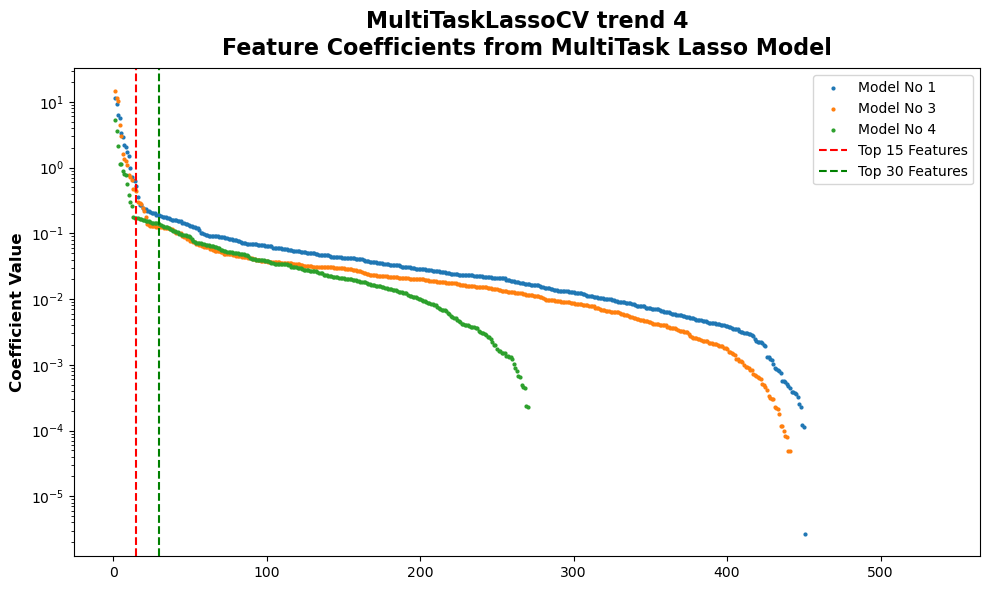

,feature,coefficient,lag_hours
523,median_decay_last_7D_lag_1,5.283343,0.08
533,median_decay_last_30D_lag_1,3.617486,0.08
516,F10.7 (LASP)_lag_1,2.116077,0.08
387,Flow Speed (km/s_lag_1,1.122584,0.08
527,median_decay_last_7D_lag_577,-1.121267,48.08
531,median_decay_last_14D_lag_433,-0.889448,36.08
530,median_decay_last_14D_lag_289,-0.812137,24.08
0,|avg B|_lag_1,0.764762,0.08
517,F10.7 (LASP)_lag_73,0.570241,6.08
129,Bz GSE_lag_1,-0.383656,0.08


In [6]:
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()

fig, ax = plt.subplots(figsize=(10, 6))
for model_No in model_Nos:
    model = models[model_No]
    y_test_pred = predicitions[model_No]
    coef_df = pd.DataFrame({
        'feature': X_test.columns,
        'coefficient': model.coef_[1, :]
    })
    coef_df = coef_df.sort_values(by='coefficient', key=abs, ascending=False)
    coef_df['lag_hours'] = coef_df['feature'].apply(lambda x: f"{int(x.split('_')[-1]) * (dt_seconds / 3600):.2f}" if 'lag' in x else np.nan)
    ax.scatter(range(1,len(coef_df)+1), abs(coef_df['coefficient']), s = 4, label=f'Model No {model_No}')
ax.axvline(x=15, color='red', linestyle='--', label='Top 15 Features')
ax.axvline(x=30, color='green', linestyle='--', label='Top 30 Features')
ax.set_ylabel('Coefficient Value')
ax.set_title(f'{model_name} {target} {model_No}\nFeature Coefficients from MultiTask Lasso Model')
ax.set_yscale('log')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

coef_df.head(10)

## Check alphas


Model No 1
Best alpha: 0.017
Mean CV MSE at Best alpha: 33.5195 ± 6.8685
Selected alpha 0.588
Mean CV MSE at Selected alpha: 35.1428 ± 7.2620

Model No 3
Best alpha: 0.020
Mean CV MSE at Best alpha: 17.2963 ± 3.9826
Selected alpha 0.588
Mean CV MSE at Selected alpha: 19.7895 ± 5.0311

Model No 4
Best alpha: 0.588
Mean CV MSE at Best alpha: 48.9954 ± 9.6282
Selected alpha 0.588
Mean CV MSE at Selected alpha: 48.9954 ± 9.6282


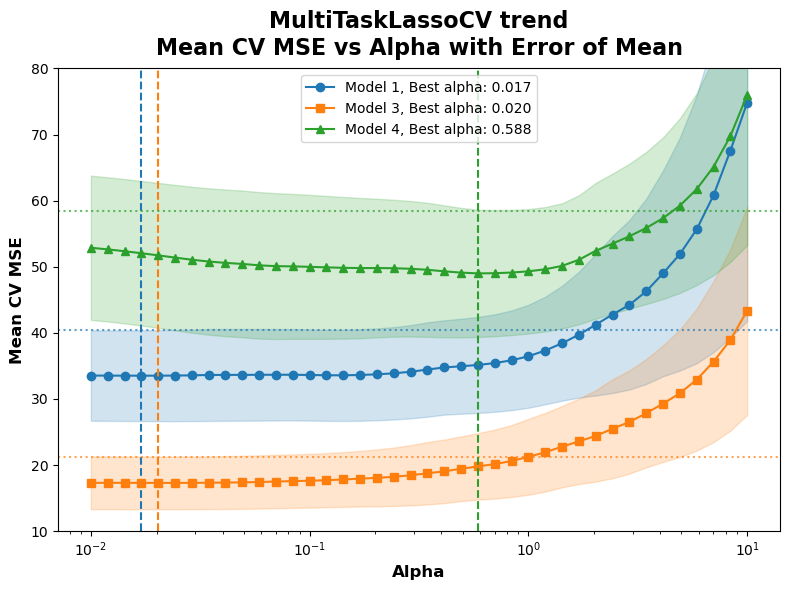

In [8]:
# check if model has an attribute alphas_
markes = ['o', 's', '^', 'D', 'v']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:cyan', 'tab:magenta']
fig, ax = plt.subplots(figsize=(8, 6))
for i, model_No in enumerate(model_Nos):
    model = models[model_No]
    alpha_mse_df = pd.DataFrame({
        "alpha": model.alphas_,
        "mean_cv_mse": model.mse_path_.mean(axis=1),
        "std_cv_mse": model.mse_path_.std(axis=1),
        "mean_cv_err": model.mse_path_.std(axis=1) / np.sqrt(model.mse_path_.shape[1])
    }).sort_values("alpha", ascending=True)
    best_alpha = model.alpha_
    ax.plot(alpha_mse_df['alpha'], alpha_mse_df['mean_cv_mse'], marker=markes[i], color=colors[i], label=f'Model {model_No}, Best alpha: {best_alpha:.3f}')
    ax.fill_between(
        alpha_mse_df['alpha'],
        alpha_mse_df['mean_cv_mse'] - alpha_mse_df['mean_cv_err'],
        alpha_mse_df['mean_cv_mse'] + alpha_mse_df['mean_cv_err'],
        color=colors[i],
        alpha=0.2
    )
    ax.axvline(best_alpha, color=colors[i], linestyle='--')
    # find biggest alpha where mean_cv_mse is within 0.5 std dev of min mean_cv_mse
    ax.axhline(alpha_mse_df['mean_cv_mse'].min() + alpha_mse_df['mean_cv_err'].min(), color=colors[i], linestyle=':', alpha=0.7)

    # print
    if True:
        selected_loc = 23
        print(f"\nModel No {model_No}")
        print(f"Best alpha: {best_alpha:.3f}")
        print(f"Mean CV MSE at Best alpha: {alpha_mse_df.loc[alpha_mse_df['alpha'] == best_alpha, 'mean_cv_mse'].values[0]:.4f}"
          f" ± {alpha_mse_df.loc[alpha_mse_df['alpha'] == best_alpha, 'mean_cv_err'].values[0]:.4f}")
        print(f"Selected alpha {alpha_mse_df.iloc[selected_loc]['alpha']:.3f}")
        print(f"Mean CV MSE at Selected alpha: {alpha_mse_df.iloc[selected_loc]['mean_cv_mse']:.4f} ± {alpha_mse_df.iloc[selected_loc]['mean_cv_err']:.4f}")
ax.set_xscale('log')
ax.set_xlabel('Alpha')
ax.set_ylabel('Mean CV MSE')
ax.set_ylim(bottom=10, top = 80)
ax.set_title(f'{model_name} {target}\nMean CV MSE vs Alpha with Error of Mean')
ax.legend()
plt.show()

## Check Test Error

Test RMSE: 11.5
Test R2: 0.271


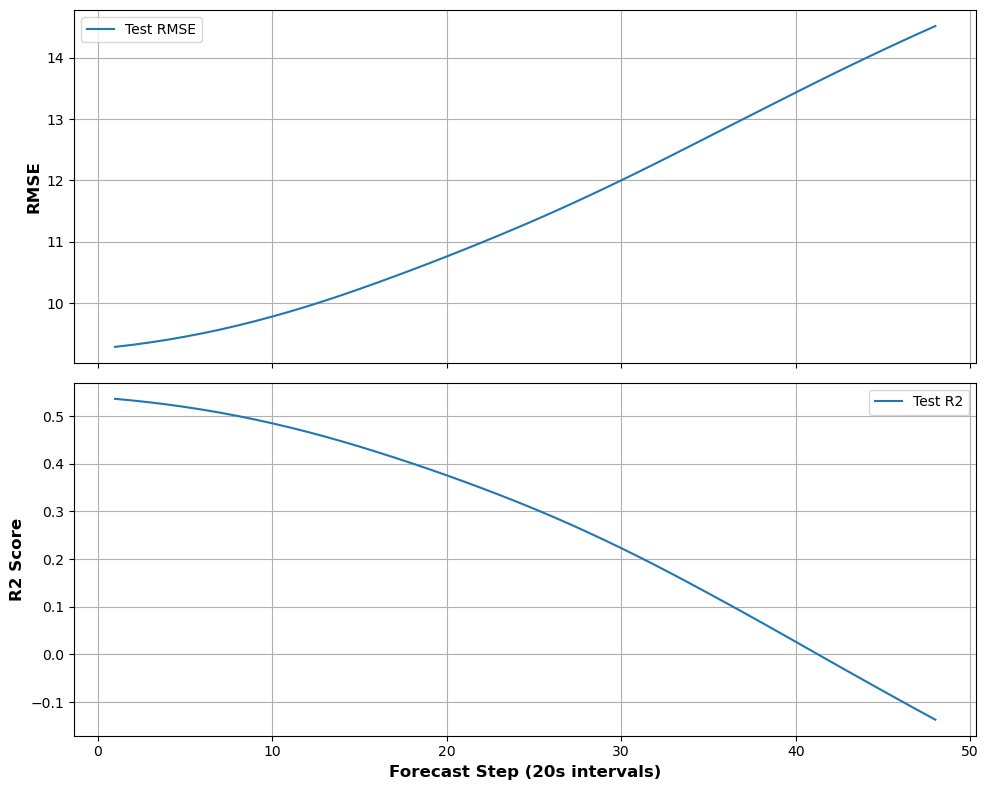

In [8]:
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print((f"Test RMSE: {test_rmse:.3}"))
test_r2 = r2_score(y_test, y_test_pred)
print((f"Test R2: {test_r2:.3}"))

test_rmse_list = []
test_r2_list = []

for i in range(len(y_test.columns)):
    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
    test_r2_list.append(r2_score(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
xtest = [int(col.split('_')[-1]) for col in y_test.iloc[0].index]
ax[0].plot(xtest,test_rmse_list, label='Test RMSE')
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(xtest, test_r2_list, label='Test R2')
ax[1].set_ylabel('R2 Score')
ax[1].set_xlabel('Forecast Step (20s intervals)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()